# PHQ-8 Depression Detection — 3-Block CNN (Regression)

**Architecture**: 3 convolutional blocks (Conv2D → BatchNorm → ReLU → MaxPool), adaptive average pooling, fully-connected layers with dropout, MSE regression head.

**Input**: log-mel spectrograms `(1, 128, 801)` saved as `.npy` files.

**Target**: PHQ-8 score (continuous, 0–24).

## 1. Imports & Configuration

In [2]:
import os
import numpy as np
import pandas as pd
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam

import matplotlib.pyplot as plt
from scipy.stats import pearsonr

In [3]:
# Paths
BASE_DIR = Path("..")
PROCESSED_DIR = BASE_DIR / "processed"
META_CSV = PROCESSED_DIR / "segment_metadata.csv"
SPEC_ROOT = PROCESSED_DIR / "spectrograms"
SAVE_DIR = BASE_DIR / "best_model" / "3_cnn_block"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# Training hyper-parameters 
BATCH_SIZE = 64
NUM_EPOCHS = 100
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-3
CHECKPOINT_FREQ = 10
EARLY_STOPPING_PATIENCE = 10   # stop if dev loss doesn't improve for this many epochs
NUM_WORKERS = 0

# Device 
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
if DEVICE.type == "cpu":
    print("  WARNING: No GPU detected — training will be significantly slower.")
print(f"Checkpoints will be saved to: {SAVE_DIR.resolve()}")

Using device: cuda
Checkpoints will be saved to: C:\Users\edgar\OneDrive\Documents\Term_8\Deep_learning\Project\phq8_depression_detection\best_model\3_cnn_block


## 2. Dataset

In [4]:
def spec_augment(spec, n_freq_masks=2, freq_mask_width=10, n_time_masks=2, time_mask_width=50):
    """
    SpecAugment: randomly zero-out horizontal (frequency) and vertical (time)
    bands of a spectrogram.  Applied in-place on a (n_mels, n_frames) tensor.
    """
    n_mels, n_frames = spec.shape
    for _ in range(n_freq_masks):
        f = torch.randint(0, freq_mask_width + 1, (1,)).item()
        f0 = torch.randint(0, max(n_mels - f, 1), (1,)).item()
        spec[f0 : f0 + f, :] = 0.0
    for _ in range(n_time_masks):
        t = torch.randint(0, time_mask_width + 1, (1,)).item()
        t0 = torch.randint(0, max(n_frames - t, 1), (1,)).item()
        spec[:, t0 : t0 + t] = 0.0
    return spec

class SpectrogramDataset(Dataset):
    def __init__(self, meta_df: pd.DataFrame, spec_root: Path, split: str):
        self.meta = meta_df.reset_index(drop=True)
        self.split_dir = spec_root / split
        self.augment = (split == "train")

    def __len__(self):
        return len(self.meta)

    def __getitem__(self, idx):
        row = self.meta.iloc[idx]
        pid = int(row["participant_id"])
        seg = int(row["segment_idx"])
        spec_path = self.split_dir / f"{pid}_seg{seg:04d}.npy"
        spec = np.load(spec_path).astype(np.float32)
        spec = torch.from_numpy(spec)                        # (128, n_frames)
        if self.augment:
            spec = spec_augment(spec)
        spec = spec.unsqueeze(0)                             # (1, 128, n_frames)
        label = torch.tensor(float(row["phq_score"]), dtype=torch.float32)
        pid_t = torch.tensor(pid, dtype=torch.long)
        return spec, label, pid_t                           # pid needed for participant-level aggregation

def build_loaders(meta_csv, spec_root, batch_size, num_workers):
    meta = pd.read_csv(meta_csv)
    splits = {}
    for split in ("train", "dev", "test"):
        df = meta[meta["split"] == split].reset_index(drop=True)
        ds = SpectrogramDataset(df, spec_root, split)
        splits[split] = DataLoader(
            ds, batch_size=batch_size, shuffle=(split == "train"),
            num_workers=num_workers, pin_memory=True
        )
        aug_str = " + SpecAugment" if ds.augment else ""
        print(f"  {split:5s}: {len(df):6,} segments{aug_str}  →  {ds.split_dir}")
    return splits

print("Building data loaders…")
loaders      = build_loaders(META_CSV, SPEC_ROOT, BATCH_SIZE, NUM_WORKERS)
train_loader = loaders["train"]
dev_loader   = loaders["dev"]
test_loader  = loaders["test"]

Building data loaders…
  train: 11,362 segments + SpecAugment  →  ..\processed\spectrograms\train
  dev  :  4,322 segments  →  ..\processed\spectrograms\dev
  test :  5,904 segments  →  ..\processed\spectrograms\test


In [5]:
# print number of control and depressed samples in each split
meta = pd.read_csv(META_CSV)
for split in ("train", "dev", "test"):
    df = meta[meta["split"] == split]
    num_control = (df["phq_score"] < 10).sum()
    num_depressed = (df["phq_score"] >= 10).sum()
    print(f"{split:5s}: {num_control:6,} control, {num_depressed:6,} depressed")

train:  8,009 control,  3,353 depressed
dev  :  2,590 control,  1,732 depressed
test :  4,281 control,  1,623 depressed


## 3. Model — 3-Block CNN Regression

In [6]:
class ConvBlock(nn.Module):
    """Conv2D → BatchNorm → ReLU → MaxPool2d"""

    def __init__(self, in_ch: int, out_ch: int, kernel: int = 3, pool: int = 2):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=kernel, padding=kernel // 2, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=pool, stride=pool),
        )

    def forward(self, x):
        return self.block(x)

class CNN3BlockRegressor(nn.Module):
    """
    3-block CNN for PHQ-8 regression.

    Input  : (B, 1, 128, 801)  — log-mel spectrogram
    Output : (B,)              — predicted PHQ-8 score
    """
    def __init__(self, dropout: float = 0.5):
        super().__init__()

        # Convolutional backbone 
        self.conv_blocks = nn.Sequential(
            ConvBlock(in_ch=1,   out_ch=32,  kernel=3, pool=2),   # → (32,  64, 400)
            ConvBlock(in_ch=32,  out_ch=64,  kernel=3, pool=2),   # → (64,  32, 200)
            ConvBlock(in_ch=64,  out_ch=128, kernel=3, pool=2),   # → (128, 16, 100)
        )

        # Adaptive pooling → fixed-size feature vector 
        self.adaptive_pool = nn.AdaptiveAvgPool2d((4, 4))          # → (128, 4, 4)

        # Regression head 
        self.head = nn.Sequential(
            nn.Flatten(),                                           # → 128*4*4 = 2048
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(256, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(64, 1),                                       # scalar output
        )

    def forward(self, x):
        x = self.conv_blocks(x)      # (B, 128, 16, ~100)
        x = self.adaptive_pool(x)    # (B, 128, 4, 4)
        x = self.head(x)             # (B, 1)
        return x.squeeze(1)          # (B,)

model = CNN3BlockRegressor(dropout=0.5).to(DEVICE)

# Quick shape sanity-check
with torch.no_grad():
    dummy = torch.zeros(2, 1, 128, 801, device=DEVICE)
    out = model(dummy)
    print(f"Output shape: {out.shape}  (expected: (2,))")

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {total_params:,}")

Output shape: torch.Size([2])  (expected: (2,))
Trainable parameters: 633,953


## 4. Training Loop

In [8]:
criterion = nn.MSELoss()
optimizer = Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

history = {"train_loss": [], "dev_loss": [], "dev_rmse": []}
best_dev_loss = float("inf")
epochs_no_improve = 0

def train_epoch(loader):
    """Segment-level training pass."""
    model.train()
    total_loss, total_samples = 0.0, 0
    with torch.enable_grad():
        for specs, labels, _ in loader:
            specs  = specs.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)
            preds  = model(specs)
            loss   = criterion(preds, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss    += loss.item() * len(labels)
            total_samples += len(labels)
    return total_loss / total_samples

def evaluate_segment(loader):
    """Segment-level evaluation — used for early stopping and dev monitoring."""
    model.eval()
    total_loss, total_samples = 0.0, 0
    with torch.no_grad():
        for specs, labels, _ in loader:
            specs  = specs.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)
            preds  = model(specs)
            loss   = criterion(preds, labels)
            total_loss    += loss.item() * len(labels)
            total_samples += len(labels)
    mse  = total_loss / total_samples
    rmse = mse ** 0.5
    return mse, rmse

def evaluate_participant(loader):
    """
    Participant-level evaluation.
    Runs inference on every segment, then averages each participant's
    segment predictions into one score before computing metrics.
    """
    model.eval()
    records = []
    with torch.no_grad():
        for specs, labels, pids in loader:
            specs = specs.to(DEVICE, non_blocking=True)
            preds = model(specs).cpu().numpy()
            for pid, pred, label in zip(pids.numpy(), preds, labels.numpy()):
                records.append((int(pid), float(pred), float(label)))

    df = pd.DataFrame(records, columns=["participant_id", "pred", "label"])
    agg = df.groupby("participant_id").agg(
        pred  = ("pred",  "mean"),
        label = ("label", "first"),
    ).reset_index()

    mse  = float(np.mean((agg["pred"].values - agg["label"].values) ** 2))
    rmse = mse ** 0.5
    return mse, rmse, agg

for epoch in range(1, NUM_EPOCHS + 1):

    train_mse = train_epoch(train_loader)
    dev_mse, dev_rmse = evaluate_segment(dev_loader)

    history["train_loss"].append(train_mse)
    history["dev_loss"].append(dev_mse)
    history["dev_rmse"].append(dev_rmse)

    print(f"Epoch [{epoch}/{NUM_EPOCHS}], Train MSE: {train_mse:.4f}, Dev MSE: {dev_mse:.4f}, Dev RMSE: {dev_rmse:.4f}")

    # Checkpoint
    if epoch % CHECKPOINT_FREQ == 0:
        ckpt_path = SAVE_DIR / f"epoch{epoch}_3cnn.pth"
        torch.save({
            "epoch":                epoch,
            "model_state_dict":     model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "train_mse":            train_mse,
            "dev_mse":              dev_mse,
        }, ckpt_path)
        print(f"  Checkpoint saved -> {ckpt_path.name}")

    # Save best / early stopping (segment-level dev MSE)
    if dev_mse < best_dev_loss:
        best_dev_loss     = dev_mse
        epochs_no_improve = 0
        best_path = SAVE_DIR / "3_cnn_best.pth"
        torch.save({
            "epoch":                epoch,
            "model_state_dict":     model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "dev_mse":              dev_mse,
            "dev_rmse":             dev_rmse,
        }, best_path)
        print(f"  Best model saved -> {best_path.name}  (dev MSE {dev_mse:.4f})")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= EARLY_STOPPING_PATIENCE:
            print(f"\n  Early stopping triggered — no improvement for {EARLY_STOPPING_PATIENCE} epochs.")
            break

print("\nTraining complete.")
print(f"Best dev MSE (segment) : {best_dev_loss:.4f}  |  RMSE : {best_dev_loss**0.5:.4f}")

Epoch [1/100], Train MSE: 27.8303, Dev MSE: 58.1871, Dev RMSE: 7.6280
  Best model saved -> 3_cnn_best.pth  (dev MSE 58.1871)
Epoch [2/100], Train MSE: 27.0164, Dev MSE: 58.8835, Dev RMSE: 7.6736
Epoch [3/100], Train MSE: 26.4598, Dev MSE: 57.7620, Dev RMSE: 7.6001
  Best model saved -> 3_cnn_best.pth  (dev MSE 57.7620)
Epoch [4/100], Train MSE: 25.8042, Dev MSE: 51.2761, Dev RMSE: 7.1607
  Best model saved -> 3_cnn_best.pth  (dev MSE 51.2761)
Epoch [5/100], Train MSE: 25.3659, Dev MSE: 55.9091, Dev RMSE: 7.4772
Epoch [6/100], Train MSE: 24.7758, Dev MSE: 52.4257, Dev RMSE: 7.2406
Epoch [7/100], Train MSE: 24.5538, Dev MSE: 56.8924, Dev RMSE: 7.5427
Epoch [8/100], Train MSE: 23.9746, Dev MSE: 60.6778, Dev RMSE: 7.7896
Epoch [9/100], Train MSE: 23.3680, Dev MSE: 81.7703, Dev RMSE: 9.0427
Epoch [10/100], Train MSE: 22.9092, Dev MSE: 63.0395, Dev RMSE: 7.9397
  Checkpoint saved -> epoch10_3cnn.pth
Epoch [11/100], Train MSE: 22.6145, Dev MSE: 59.8123, Dev RMSE: 7.7338
Epoch [12/100], Train

## 5. Training Curves

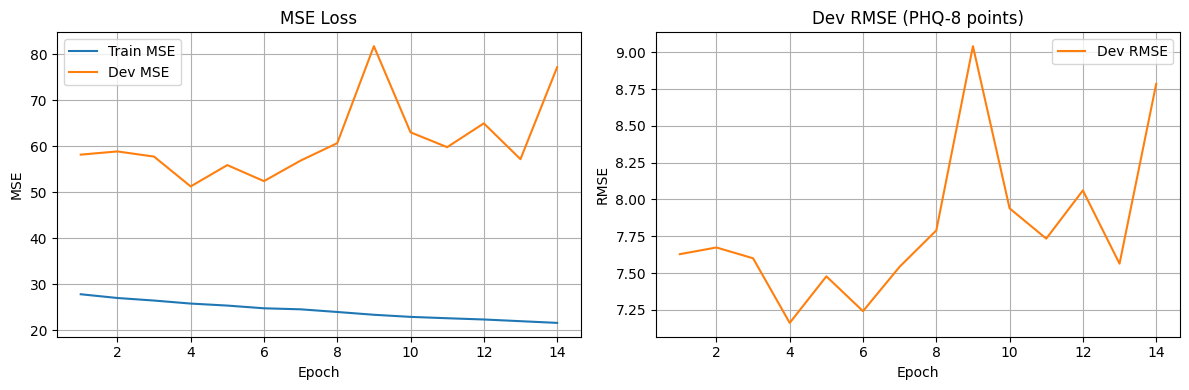

In [9]:
epochs = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, history["train_loss"], label="Train MSE")
axes[0].plot(epochs, history["dev_loss"],   label="Dev MSE")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE")
axes[0].set_title("MSE Loss")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epochs, history["dev_rmse"], color="tab:orange", label="Dev RMSE")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("RMSE")
axes[1].set_title("Dev RMSE (PHQ-8 points)")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 6. Evaluation on Test Set

Load the best model and evaluate on the held-out test split. Metrics reported:
- **MSE** — mean squared error
- **RMSE** — root MSE (in PHQ-8 points)
- **MAE** — mean absolute error
- **Pearson r** — correlation between predicted and true scores

In [10]:
# Load best weights
best_ckpt = torch.load(SAVE_DIR / "3_cnn_best.pth", map_location=DEVICE, weights_only=True)
model.load_state_dict(best_ckpt["model_state_dict"])
print(f"Loaded best model from epoch {best_ckpt['epoch']}  "
      f"(dev MSE {best_ckpt['dev_mse']:.4f})")

# Participant-level predictions on test set
_, _, test_agg = evaluate_participant(test_loader)

all_preds  = test_agg["pred"].values
all_labels = test_agg["label"].values

print(f"  Participants evaluated: {len(test_agg)}")

# Metrics
test_mse  = float(np.mean((all_preds - all_labels) ** 2))
test_rmse = test_mse ** 0.5
test_mae  = float(np.mean(np.abs(all_preds - all_labels)))
test_r, _ = pearsonr(all_preds, all_labels)

print("\n── Test-set results (participant level) ───────────")
print(f"  MSE       : {test_mse:.4f}")
print(f"  RMSE      : {test_rmse:.4f}  PHQ-8 points")
print(f"  MAE       : {test_mae:.4f}  PHQ-8 points")
print(f"  Pearson r : {test_r:.4f}")

Loaded best model from epoch 4  (dev MSE 51.2761)
  Participants evaluated: 47

── Test-set results (participant level) ───────────
  MSE       : 41.0974
  RMSE      : 6.4107  PHQ-8 points
  MAE       : 5.4860  PHQ-8 points
  Pearson r : 0.1081


## 7. Prediction Distribution

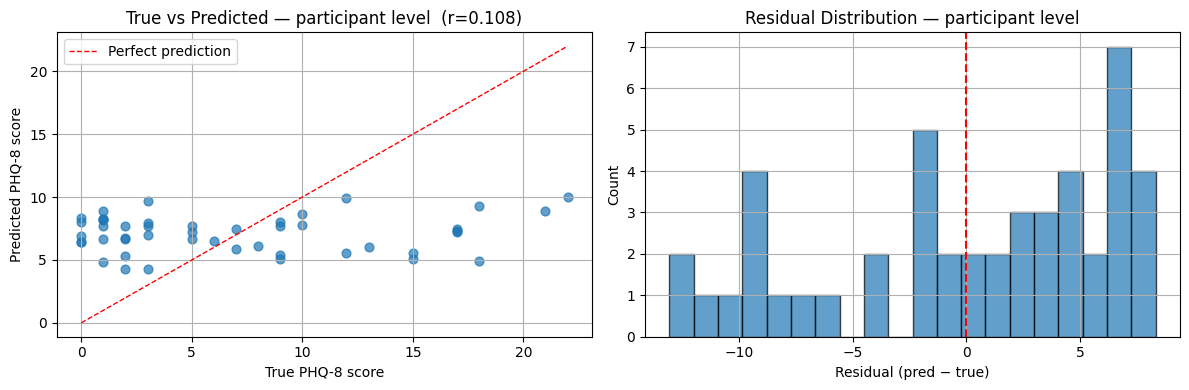

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# One point per participant
axes[0].scatter(all_labels, all_preds, alpha=0.7, s=40)
lo, hi = min(all_labels.min(), all_preds.min()), max(all_labels.max(), all_preds.max())
axes[0].plot([lo, hi], [lo, hi], "r--", linewidth=1, label="Perfect prediction")
axes[0].set_xlabel("True PHQ-8 score")
axes[0].set_ylabel("Predicted PHQ-8 score")
axes[0].set_title(f"True vs Predicted — participant level  (r={test_r:.3f})")
axes[0].legend()
axes[0].grid(True)

residuals = all_preds - all_labels
axes[1].hist(residuals, bins=20, edgecolor="k", alpha=0.7)
axes[1].axvline(0, color="r", linestyle="--")
axes[1].set_xlabel("Residual (pred − true)")
axes[1].set_ylabel("Count")
axes[1].set_title("Residual Distribution — participant level")
axes[1].grid(True)

plt.tight_layout()
plt.show()